In [14]:
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os
from tqdm import tqdm
from langchain.messages import HumanMessage
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
llm = ChatOpenAI(model="gpt-4o-mini",temperature=0)
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

In [16]:
CONNECTION_STRING = os.environ.get("CONNECTION_STRING","")
SUPERBASE_SERVICE_ROLE_KEY = os.environ.get("SUPERBASE_SERVICE_ROLE_KEY","")
SUPABASE_URL = os.environ.get("SUPABASE_URL","")

In [17]:
from supabase import create_client

supabase_client = create_client(SUPABASE_URL,SUPERBASE_SERVICE_ROLE_KEY)

collection_name = "haseeb_portfolio"

print("Succefully coonectd to Supabase client")

Succefully coonectd to Supabase client


In [21]:
from langchain_core.prompts import PromptTemplate


template = PromptTemplate(
    template="""You are a personal AI assistant for Haseeb Manzoor.

Answer questions about Haseeb Manzoor using ONLY the context provided below.
Do NOT use outside knowledge or assumptions.

IMPORTANT RULES:
- Keep answers SHORT and focused (2–3 sentences maximum).
- Give a brief summary, not a full biography.
- Do NOT include contact details, location, or age unless explicitly asked.
- Questions mentioning "Haseeb", "you", or "he/him" refer to Haseeb Manzoor.
- If the context does not contain the answer, say exactly:
  "I don't have that information in the context provided."

CONTEXT:
{context}

QUESTION: {question}

ANSWER (concise):""",
    input_variables=["context", "question"]
)


In [19]:
from typing import List, TypedDict
from langchain_core.messages import BaseMessage
from typing_extensions import Annotated
from langgraph.graph.message import add_messages
from langchain_core.documents import Document

class ChatState(TypedDict):
    # question: str
    context: str
    answer: str
    messages: Annotated[list[BaseMessage], add_messages]
    collection_name: str
    retrieved_docs: List[Document]


# DOcument Ingestion

In [20]:
from langchain_core.documents import Document
import json

from langchain_text_splitters import RecursiveCharacterTextSplitter
from sqlalchemy import NullPool
from langchain_postgres import PGVector
from tqdm import tqdm



class PGVectorStoreCreation:

    def __init__(self,embedding_model,connection_string,data_path,collection_name=collection_name):
        self.connection_string = connection_string
        self.collection_name = collection_name   
        self.embedding_model = embedding_model
        self.data_path =  data_path
        self.batch_size = 50


    def data_loader(self):
        with open(self.data_path,"r",encoding="utf-8") as f:
            json_data = json.load(f)

            documents = [Document(page_content=item["text"],
                        metadata={**item["metadata"],"id":item["id"]})
                        for item in json_data]
            
        return documents
        

    def text_splitter(self):
        splitter = RecursiveCharacterTextSplitter(chunk_size=150,chunk_overlap=35)
        
        #split documne texpect list
        all_chunk = []
        for doc in self.data_loader():
            # split the document into chunks
            chunks = splitter.split_documents([doc])

            for chunk in chunks:
                chunk.metadata.update({
                "id":doc.metadata.get("id","unknown"),
                "category":doc.metadata.get("category","unknown"),
                "topic":doc.metadata.get("topic","unknown")
                })
            all_chunk.extend(chunks)
        return all_chunk


    def create_vector_store(self,chunks):
        vectorstore = PGVector(
                embeddings=self.embedding_model,
                collection_name=self.collection_name,
                connection=self.connection_string,
                use_jsonb=True,
                engine_args={"poolclass": NullPool}  # disable pooling
            ) #type:ignore
        

        # uploading embedding to supbase
        for i in tqdm(range(0,len(chunks),self.batch_size),desc="Uploading Embedding Vectors..."):
            batch = chunks[i:i+self.batch_size]
            vectorstore.add_documents(batch)
    
        # inseting metadata in to supabase
        rows = [
            {
            "doc_id":self.collection_name,
            "chunk_index":i,
            "page":chunk.metadata.get("page"),
            "content":chunk.page_content,
        } for i,chunk in enumerate(chunks)
        ]

        if rows:
            supabase_client.table("portfolio").insert(rows).execute()
        print("Vector store created successfully")
        return vectorstore




if __name__=="__main__":
    creator = PGVectorStoreCreation(
    embedding_model=embedding_model,
    connection_string=CONNECTION_STRING,
    data_path="../data/chat.json"
) #type:ignore


chunks = creator.text_splitter()
vector_store = creator.create_vector_store(chunks)

Uploading Embedding Vectors...: 100%|██████████| 1/1 [00:07<00:00,  7.01s/it]


Vector store created successfully


# Lnaggraph Part

In [22]:
from langchain_core.documents import Document
from langchain_postgres import PGVector
from sqlalchemy.pool import NullPool

def retriever(state: ChatState):     
    vectorstore = PGVector(
        connection=CONNECTION_STRING,
        collection_name=state["collection_name"],
        embeddings=embedding_model,
        use_jsonb=True
    ) #type:ignore

    retriever = vectorstore.as_retriever(
        search_type="similarity",
        search_kwargs={
            "k": 5
        }
    )

    humman_message = state["messages"][-1].content
    retrieved_docs = retriever.invoke(humman_message)

    state["retrieved_docs"] = retrieved_docs
    return state

In [23]:
from langchain.messages import AIMessage, HumanMessage

def agent(state:ChatState):
    # 1 builld context
    retrieved_docs = state.get("context","")
    context = "\n\n".join([doc.page_content for doc in state["retrieved_docs"]])

    #2 get last humman message
    human_message = [m for m in state["messages"] if isinstance(m, HumanMessage)][-1].content

    #3 format prompt
    prompt = template.format(context=context, question=human_message)

    # call llm
    response = llm.invoke(prompt)

    return {
        "messages":state["messages"] + [AIMessage(content=response.content)],
        "answer": response.content,
        "context": context
    }


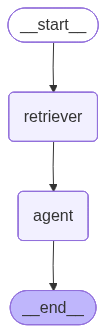

In [24]:
from langgraph.graph.state import StateGraph,START,END


workflow = StateGraph(ChatState)

workflow = StateGraph(ChatState)
workflow.add_node(retriever,"retriever")
workflow.add_node(agent,"agent")

workflow.add_edge(START,"retriever")
workflow.add_edge("retriever","agent")
workflow.add_edge("agent",END)


app = workflow.compile()
app

In [41]:
# from langgraph.checkpoint.base import Checkpoint

# class PostgresCheckpoint(Checkpoint):
#     def __init__(self, supabase_client, table_name="chat_memory"):
#         self.client = supabase_client
#         self.table_name = table_name

#     def save(self, state: dict, key: str):
#         self.client.table(self.table_name).insert({"id": key,"state": state}).execute()

#     def load(self, key: str):
#         result = self.client.table(self.table_name).select("*").eq("id", key).execute()
#         if result.data:
#             return result.data[0]["state"]
#         return None


In [25]:
from langgraph.checkpoint.postgres import PostgresSaver
thread_id = "thread_1"


with PostgresSaver.from_conn_string(CONNECTION_STRING) as checkpointer:
    checkpointer.setup() # run once

    graph = workflow.compile(checkpointer=checkpointer)
    config = {"configurable": {"thread_id": thread_id}}

    initial_state = {
        "collection_name": collection_name,
        "messages": [HumanMessage(content="Who is Haseeb Manzoor?")]
    }
    result = graph.invoke(initial_state,config=config)
    print("answer",result["answer"])
    

answer Haseeb Manzoor is an AI Engineer with expertise in Machine Learning, Deep Learning, and Generative AI. He is skilled in Python and Java, and has hands-on experience with tools like TensorFlow, PyTorch, and LangChain.


In [26]:
from IPython.display import Markdown, display
Markdown(result["answer"])

Haseeb Manzoor is an AI Engineer with expertise in Machine Learning, Deep Learning, and Generative AI. He is skilled in Python and Java, and has hands-on experience with tools like TensorFlow, PyTorch, and LangChain.